# 2 · A bilinear-interpolation baseline for downscaling (O96 1° → N320 ~0.25°)

In notebook&nbsp;1 we met the data and the WeatherGenerator. Now we build the
**baseline** that our learned downscaling will be measured against.

**Downscaling** (a.k.a. *super-resolution*) takes a coarse field and produces a finer one.
The simplest possible method is **interpolation**: just draw smooth values between the
coarse points. It is fast, needs no training, and is surprisingly hard to beat on average
error — which is exactly why it makes a good baseline.

### The grids: both are *reduced Gaussian*

A crucial detail for this hackathon: **neither** the source **nor** the target is a regular
latitude/longitude box.

| | grid | ~resolution | # points | structure |
|---|---|---|---|---|
| **source** (input) | O96 octahedral | ~1° | 40&nbsp;320 | reduced Gaussian (unstructured) |
| **target** (output) | **N320** | ~0.25° | 542&nbsp;080 | reduced Gaussian (unstructured) |

So the baseline is an **unstructured → unstructured** interpolation: we predict the value at
each of the 542&nbsp;080 N320 points from the 40&nbsp;320 O96 points — a **~13.4×** increase in
the number of grid points.

> 🗂️ **Note on data.** The EERIE **N320 target** is not on this HPC yet. Until it arrives we
> use a matched **ERA5 O96 / N320** pair (same 101 variables, same 6-hourly dates) as a
> stand-in — this gives us **real** coarse *and* fine fields at the same timestamps, so we
> can score the baseline against a true target today. Swapping to EERIE later is a one-line
> change of the dataset names in the config cell.

In this notebook we will:

1. Load the coarse **O96 source** and the fine **N320 target**.
2. **Bilinearly interpolate** the O96 (1°) field onto the N320 points and look at it.
3. Put a **number** on the baseline by scoring the interpolation against the **true N320
   field** (RMSE).
4. Understand *why* interpolation blurs — and why a generative model like WG can do better.


## What is (bi)linear interpolation?

- **1-D linear interpolation** between two known values $f_0, f_1$ a fraction $t\in[0,1]$
  of the way across: $f(t) = (1-t)\,f_0 + t\,f_1$ — a straight line.
- **Bilinear interpolation** does this in 2-D: linear in one direction, then linear in the
  other, using the four surrounding grid values. It is the standard “smooth zoom” you get
  from image-resizing tools.

Both our grids are **unstructured** point clouds (reduced Gaussian), not regular images, so
there is no clean 2×2 box of neighbours. The unstructured generalisation of bilinear
interpolation is **linear interpolation on a triangulation**: connect the source points
into triangles and, inside each triangle, blend its three corner values linearly.
`scipy.interpolate.griddata` with `method="linear"` does exactly this, and it can be queried
at arbitrary target points — which is exactly what we need to hit the N320 locations.


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.interpolate import griddata
from anemoi.datasets import open_dataset

# ----------------------------------------------------------------------
# CONFIG — data paths (edit these to point at different data / another HPC)
# ----------------------------------------------------------------------
# All datasets live under one root, so switching machines is a one-line change.
# Override without editing the notebook by setting the DATA_ROOT env var.
DATA_ROOT = os.environ.get("DATA_ROOT", "/e/data1/slmet/ml_training")

# Coarse source (~1°, O96) and fine target (~0.25°, N320). We use a matched
# ERA5 O96/N320 pair (same 101 variables, same 6-hourly dates 1979–2023) as a
# stand-in for EERIE until the EERIE N320 target is copied to this HPC. To move
# to EERIE later, change only these two names (and DATA_ROOT if it differs).
SRC_NAME = "aifs-ea-an-oper-0001-mars-o96-1979-2023-6h-v8.zarr"    # coarse O96 (~1°)
TGT_NAME = "aifs-ea-an-oper-0001-mars-n320-1979-2023-6h-v8.zarr"   # fine   N320 (~0.25°)

SRC_PATH = os.path.join(DATA_ROOT, SRC_NAME)
TGT_PATH = os.path.join(DATA_ROOT, TGT_NAME)

# --- source: coarse atmospheric state on the O96 grid ---
src = open_dataset(SRC_PATH)
lon_src = np.asarray(src.longitudes)   # O96 point longitudes, [0, 360)
lat_src = np.asarray(src.latitudes)    # O96 point latitudes
print("source O96 grid points:", lon_src.size)


source O96 grid points: 40320


In [15]:
import datetime

def index_for_date(ds, when):
    dates = np.array(ds.dates, dtype="datetime64[s]")
    return int(np.argmin(np.abs(dates - np.datetime64(when))))

t_idx = index_for_date(src, datetime.datetime(2000, 7, 1, 12))
var = "2t"                                   # 2 m temperature (no NaNs, easy to look at)
v_idx = src.name_to_index[var]
field_src = src[t_idx][v_idx, 0, :]          # (40320,) on the O96 grid
print("field", var, "at", src.dates[t_idx], "->", field_src.shape)

field 2t at 2000-07-01T12:00:00 -> (40320,)


## Step 1 — Load the N320 target

N320 is a reduced Gaussian grid with **640 latitude rings** and **542&nbsp;080** points, at
roughly **0.25°** spacing. Like O96 it has fewer longitude points near the poles, so it is
*not* a regular grid — we get flat arrays of point coordinates.

We read both its **geometry** (`latitudes`/`longitudes`) and the **real field values** at the
same timestamp as the source, so we can compare the interpolation against a true target.
When the EERIE N320 data arrives, just point `TGT_NAME` at it.


In [16]:
# The target dataset provides BOTH the N320 grid geometry AND real values at the
# same timestamps, so we can score the interpolation against a true fine field.
tgt = open_dataset(TGT_PATH)
lon_tgt = np.asarray(tgt.longitudes)    # N320 point longitudes
lat_tgt = np.asarray(tgt.latitudes)     # N320 point latitudes

# true target field, same variable and date as the source
t_idx_tgt = index_for_date(tgt, src.dates[t_idx])
v_idx_tgt = tgt.name_to_index[var]
field_tgt_true = tgt[t_idx_tgt][v_idx_tgt, 0, :]   # (542080,) true N320 field

print(f"target N320 grid points : {lon_tgt.size:,}")
print(f"latitude rings          : {len(np.unique(np.round(lat_tgt, 4)))}")
print(f"upsampling factor        : {lon_tgt.size / lon_src.size:.1f}x  (O96 -> N320)")
print(f"true target             : {var} at {tgt.dates[t_idx_tgt]}")


target N320 grid points : 542,080
latitude rings          : 640
upsampling factor        : 13.4x  (O96 -> N320)
true target             : 2t at 2000-07-01T12:00:00


## Step 2 — Interpolate O96 → N320

We interpolate the O96 field directly onto the 542&nbsp;080 N320 point locations. Two
practical details:

- **Longitude is periodic.** The map wraps around at 0°/360°. If we ignore this, the
  triangulation leaves a seam there. We fix it by duplicating the source points shifted by
  ±360° so the triangulation spans the wrap-around.
- **NaNs.** We interpolate only from finite source points, and fill any target points that
  fall outside the triangulation (e.g. right at the poles) with nearest-neighbour values.

In [17]:
def interp_to_points(lon_s, lat_s, values, lon_q, lat_q, method="linear"):
    """Interpolate unstructured (lon_s, lat_s, values) onto arbitrary query points.

    method="linear"  -> linear interpolation on a Delaunay triangulation
                        (the unstructured analogue of bilinear).
    method="nearest" -> nearest-neighbour (blocky), shown for comparison.
    Handles longitude periodicity and NaNs. Returns a 1-D array (one value per query).
    """
    m = np.isfinite(values)
    ls, as_, vs = lon_s[m], lat_s[m], values[m]
    # periodic padding in longitude
    lon_aug = np.concatenate([ls, ls - 360.0, ls + 360.0])
    lat_aug = np.concatenate([as_, as_, as_])
    val_aug = np.concatenate([vs, vs, vs])
    out = griddata((lon_aug, lat_aug), val_aug, (lon_q, lat_q), method=method)
    holes = np.isnan(out)
    if holes.any():
        out[holes] = griddata((lon_aug, lat_aug), val_aug,
                              (lon_q[holes], lat_q[holes]), method="nearest")
    return out


def rmse(a, b):
    """NaN-safe root-mean-square error over the points where both are finite."""
    m = np.isfinite(a) & np.isfinite(b)
    return float(np.sqrt(np.mean((a[m] - b[m]) ** 2)))


In [18]:
# Builds a triangulation of ~120k source points and queries 542k N320 points: ~2 s.
field_bilinear = interp_to_points(lon_src, lat_src, field_src, lon_tgt, lat_tgt,
                                  method="linear")
field_nearest  = interp_to_points(lon_src, lat_src, field_src, lon_tgt, lat_tgt,
                                  method="nearest")
print("N320 bilinear field:", field_bilinear.shape,
      "| range %.1f–%.1f K" % (np.nanmin(field_bilinear), np.nanmax(field_bilinear)))

N320 bilinear field: (542080,) | range 203.8–324.6 K


### Look at the result

The N320 target is unstructured, so we visualise it with a **scatter** plot (one dot per
grid point), just like we did for the O96 source in notebook&nbsp;1. Globally the
interpolated field looks like the source — as it should. The interesting differences are
**local**, so we also zoom into a region with sharp gradients.

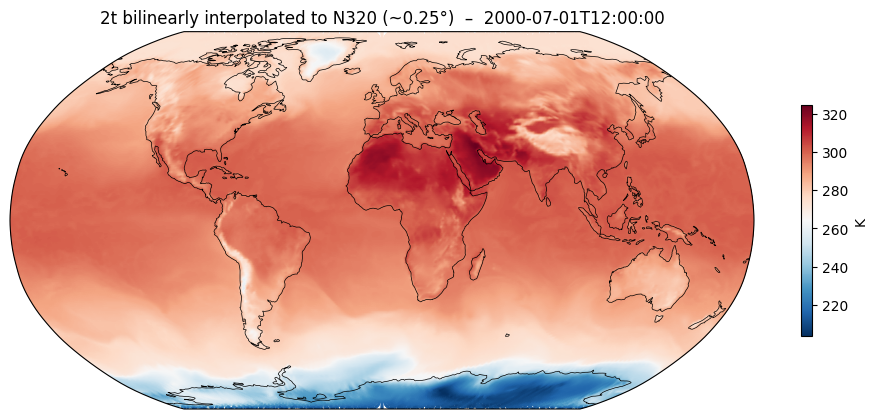

In [19]:
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(linewidth=0.5); ax.set_global()
sc = ax.scatter(lon_tgt, lat_tgt, c=field_bilinear, s=0.6, cmap="RdBu_r",
                transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, shrink=0.6, label="K")
ax.set_title(f"{var} bilinearly interpolated to N320 (~0.25°)  –  {src.dates[t_idx]}")
plt.show()

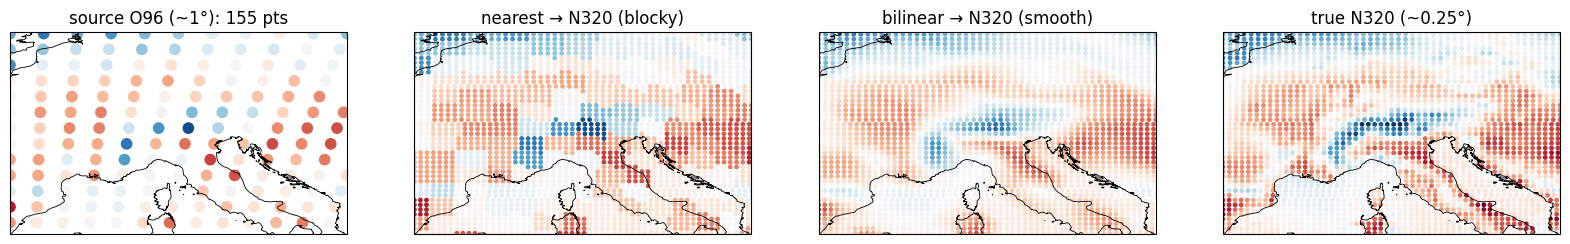

In [20]:
# Zoom on the Alps / Central Europe, where terrain makes temperature vary sharply.
lon0, lon1, lat0, lat1 = 0, 20, 40, 52

def box(lon, lat):
    return (lon >= lon0) & (lon <= lon1) & (lat >= lat0) & (lat <= lat1)

ms = box(lon_src, lat_src)     # source O96 points in the box
mt = box(lon_tgt, lat_tgt)     # target N320 points in the box
vmin, vmax = np.nanmin(field_tgt_true[mt]), np.nanmax(field_tgt_true[mt])

panels = [
    (lon_src[ms], lat_src[ms], field_src[ms], 55, f"source O96 (~1°): {ms.sum()} pts"),
    (lon_tgt[mt], lat_tgt[mt], field_nearest[mt], 6, "nearest → N320 (blocky)"),
    (lon_tgt[mt], lat_tgt[mt], field_bilinear[mt], 6, "bilinear → N320 (smooth)"),
    (lon_tgt[mt], lat_tgt[mt], field_tgt_true[mt], 6, "true N320 (~0.25°)"),
]
fig, axes = plt.subplots(1, 4, figsize=(20, 4),
                         subplot_kw={"projection": ccrs.PlateCarree()})
for ax, (lo, la, c, s, title) in zip(axes, panels):
    ax.scatter(lo, la, c=c, s=s, cmap="RdBu_r", vmin=vmin, vmax=vmax,
               transform=ccrs.PlateCarree())
    ax.set_title(title)
    ax.coastlines(linewidth=0.6); ax.set_extent([lon0, lon1, lat0, lat1])
plt.show()


Notice how **nearest** is blocky (each fine N320 point copies its closest O96 point) while
**bilinear** is smooth. Now compare the bilinear panel with the **true N320** panel on the
right: bilinear does **not** invent the fine-scale structure that the real 0.25° field has —
no sharp mountain-valley temperature contrasts appear that were not already in the coarse
O96 points. Interpolation can only *smoothly connect* what it is given. That extra detail
(orography, coastlines, convection) is exactly what a *generative* model — the
WeatherGenerator latent diffusion — is meant to recover, which is why we expect it to beat
this baseline on sharpness and extremes.


## Step 3 — Put a number on the baseline (against the real N320 target)

Because we now have the **true N320 field** at the same timestamp, we can score the baseline
**directly**: interpolate the coarse O96 field onto the N320 points and compare against the
truth.

$$\mathrm{RMSE} = \sqrt{\tfrac{1}{N}\sum_i \big(\hat f_i - f^{\mathrm{true}}_i\big)^2}$$

where $\hat f$ is the interpolated field on the N320 points and $f^{\mathrm{true}}$ is the
real N320 field. This is the exact number your learned WG downscaling will try to beat.

> 🔁 **Switching to EERIE later** changes nothing here: point `SRC_NAME`/`TGT_NAME` at the
> EERIE O96/N320 datasets and re-run — the same `interp_to_points(O96 → N320)` is compared
> against the true N320 values.


In [21]:
# Score the O96 → N320 interpolation directly against the true N320 field
# (var = 2t, so the numbers are in Kelvin).
r_near = rmse(field_nearest,  field_tgt_true)
r_bili = rmse(field_bilinear, field_tgt_true)
print(f"O96 → N320 downscaling baseline for {var} at {tgt.dates[t_idx_tgt]}")
print(f"  RMSE nearest : {r_near:.3f} K")
print(f"  RMSE bilinear: {r_bili:.3f} K   <- baseline to beat")


O96 → N320 downscaling baseline for 2t at 2000-07-01T12:00:00
  RMSE nearest : 1.301 K
  RMSE bilinear: 0.954 K   <- baseline to beat


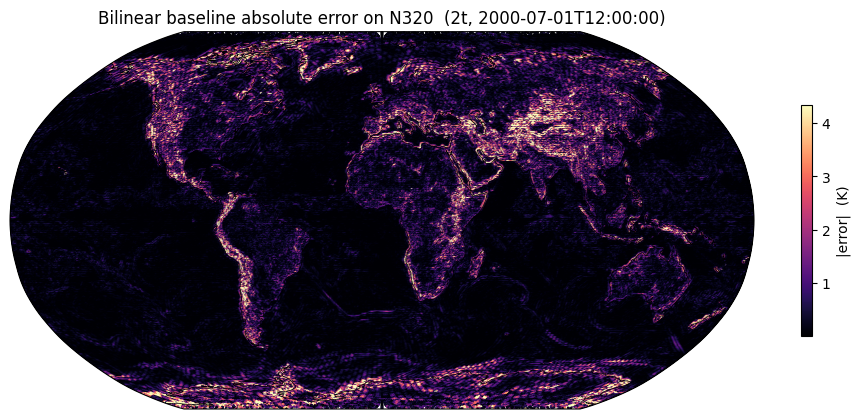

In [22]:
# Where does the baseline make its biggest errors? (Hint: mountains & coasts.)
err = np.abs(field_bilinear - field_tgt_true)
fig = plt.figure(figsize=(12, 5))
ax = plt.axes(projection=ccrs.Robinson())
ax.coastlines(linewidth=0.5); ax.set_global()
sc = ax.scatter(lon_tgt, lat_tgt, c=err, s=0.6, cmap="magma",
                vmax=np.nanpercentile(err, 99), transform=ccrs.PlateCarree())
plt.colorbar(sc, ax=ax, shrink=0.6, label="|error|  (K)")
ax.set_title(f"Bilinear baseline absolute error on N320  ({var}, {tgt.dates[t_idx_tgt]})")
plt.show()


### A quick multi-variable leaderboard

The baseline RMSE depends a lot on the variable: smooth large-scale fields (like
geopotential) interpolate almost perfectly, while sharp near-surface fields are harder. Run
the baseline for a few variables to see the spread — these are the numbers your WG model
will try to reduce.

In [23]:
def baseline_rmse_for(var_name, t_src, t_tgt):
    vi_s = src.name_to_index[var_name]
    vi_t = tgt.name_to_index[var_name]
    f_src = src[t_src][vi_s, 0, :]                 # coarse O96 field
    f_true = tgt[t_tgt][vi_t, 0, :]               # true N320 field
    f_hat = interp_to_points(lon_src, lat_src, f_src, lon_tgt, lat_tgt, method="linear")
    r = rmse(f_hat, f_true)
    sig = tgt.statistics["stdev"][vi_t]           # normalize by the variable's own std
    return r, r / sig

print(f"{'variable':>8}  {'RMSE (native units)':>20}  {'RMSE / std':>12}")
for v in ["2t", "msl", "10u", "z_500", "t_850", "q_700"]:
    r, rn = baseline_rmse_for(v, t_idx, t_idx_tgt)
    print(f"{v:>8}  {r:>20.4g}  {rn:>12.3f}")


variable   RMSE (native units)    RMSE / std
      2t                0.9535         0.061
     msl                 46.71         0.041
     10u                  0.72         0.131
   z_500                 12.32         0.004
   t_850                0.4401         0.035
   q_700             0.0003314         0.120


## 🧪 Your turn

1. **Nearest vs bilinear vs cubic.** `griddata` also supports `method="cubic"`. Compare all
   three O96→N320 interpolations on `2t` in the Alps zoom and against the true N320 field.
   Does cubic lower the RMSE? Where does it look better?
2. **A harder variable.** Repeat the zoom + RMSE for `10u` (10&nbsp;m wind) or `q_925`
   (near-surface humidity). These have more small-scale structure — how much bigger is the
   gap to the true N320 field than for `2t`?
3. **Precipitation.** Score `tp` (total precipitation). It is spiky and non-Gaussian —
   expect interpolation to struggle. This is a good target for the generative model to beat.
4. **Average over time.** Compute the bilinear baseline RMSE for `2t` over, say, 10 random
   dates (matching source/target indices) and report the mean ± std. A single date can be
   lucky; the hackathon score should be an average.
5. **Peek at the target grid.** Scatter-plot just the N320 points in a small box next to the
   O96 points (as in the zoom cell). Roughly how many N320 points fall between two
   neighbouring O96 points? That gap is the detail the model must invent.
6. **Switch datasets.** Point `SRC_NAME`/`TGT_NAME` at a different O96/N320 pair (or the
   EERIE data once it lands) and re-run the whole notebook — nothing else should need to
   change.


## Recap & what’s next

You built a real downscaling **baseline**: bilinear interpolation from the O96 (1°) grid to
the **N320 (~0.25°)** target points, scored with **RMSE against the true N320 field**. You
also saw its fundamental limitation — it **smooths** rather than **generates**, so it misses
the fine-scale detail that the real N320 field has.

➡️ **Next (upcoming notebook):** drive the **WeatherGenerator latent diffusion** model to
downscale the same 1° states. We will encode the coarse O96 state into the HEALPix latent,
run the diffusion forecast engine in *downscaling* mode, and decode at the **N320
coordinates** — then compare its RMSE **and** its sharpness against this bilinear baseline.
